In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

In [2]:
# Import Train, Test

import pickle

with open("allDataset.pkl", "rb") as f:
  allDataset = pickle.load(f)

with open("x_train_cnn.pkl", "rb") as f:
  x_train_cnn = pickle.load(f)

with open("y_train_cnn.pkl", "rb") as f:
  y_train_cnn = pickle.load(f)

with open("x_test_cnn.pkl", "rb") as f:
  x_test_cnn = pickle.load(f)

with open("y_test_cnn.pkl", "rb") as f:
  y_test_cnn = pickle.load(f)

with open("x_train_ann.pkl", "rb") as f:
  x_train = pickle.load(f)

with open("y_train_ann.pkl", "rb") as f:
  y_train = pickle.load(f)

with open("x_test_ann.pkl", "rb") as f:
  x_test = pickle.load(f)

with open("y_test_ann.pkl", "rb") as f:
  y_test = pickle.load(f)

In [ ]:
# Y Labels

y_train_labels = np.argmax(y_train, axis = 1)
y_test_labels = np.argmax(y_test, axis = 1)

3


In [6]:
# Final Classification

import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout

cnn_tf_model = tf.keras.models.load_model("cnn_tf_model.keras")
cnn_predictions_train = cnn_tf_model.predict(x_train_cnn)
cnn_predictions_test = cnn_tf_model.predict(x_test_cnn)

final_x_train = np.concatenate([cnn_predictions_train, x_train], axis = 1)
final_x_test = np.concatenate([cnn_predictions_test, x_test], axis = 1)

151/151 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 209ms/step


In [17]:
# Initalize Models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

logistic_clf = LogisticRegression(multi_class = "multinomial", max_iter = 1000)
rf_clf = RandomForestClassifier(n_estimators = 100)
knn_clf = KNeighborsClassifier(n_neighbors = 5)
svm_clf = SVC(probability = True)
xgb_clf = xgb.XGBClassifier(use_label = False, eval_metric = "mlogloss")

In [18]:
# Fit Each Model

logistic_clf.fit(final_x_train, y_train_labels)
rf_clf.fit(final_x_train, y_train_labels)
knn_clf.fit(final_x_train, y_train_labels)
svm_clf.fit(final_x_train, y_train_labels)
xgb_clf.fit(final_x_train, y_train_labels)

c:\Program Files\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Program Files\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:35:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [ ]:
# Predictions Of Each Model

logistic_pred = logistic_clf.predict(final_x_test)
rf_pred = rf_clf.predict(final_x_test)
knn_pred = knn_clf.predict(final_x_test)
svm_pred = svm_clf.predict(final_x_test)
xgb_pred = xgb_clf.predict(final_x_test)

In [22]:
# Accuracy Of Each Model

from sklearn.metrics import accuracy_score

logistic_acc = accuracy_score(y_test_labels, logistic_pred)
rf_acc = accuracy_score(y_test_labels, rf_pred)
knn_acc = accuracy_score(y_test_labels, knn_pred)
svm_acc = accuracy_score(y_test_labels, svm_pred)
xgb_acc = accuracy_score(y_test_labels, xgb_pred)

In [25]:
# Print Accuracy

print(f"Logistic Regression Accuracy: {logistic_acc}")
print(f"Random Forest Accuracy: {rf_acc}")
print(f"KNN Accuracy: {knn_acc}")
print(f"SVM Accuracy: {svm_acc}")
print(f"XGBoost Accuracy: {xgb_acc}")

Logistic Regression Accuracy: 0.7713871435476075
Random Forest Accuracy: 0.9313678105364911
KNN Accuracy: 0.8434026099565007
SVM Accuracy: 0.8390526824552924
XGBoost Accuracy: 0.9333011116481392


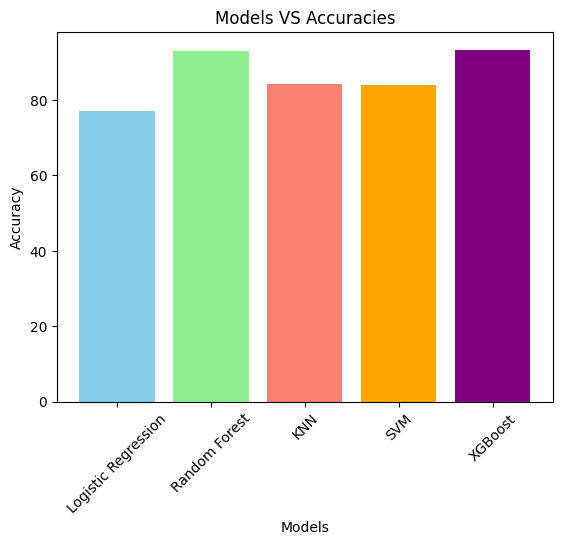

In [31]:
# Plot Accuracies

models = ["Logistic Regression", "Random Forest", "KNN", "SVM", "XGBoost"]
accuracies = [logistic_acc * 100, rf_acc * 100, knn_acc * 100, svm_acc * 100, xgb_acc * 100]
colors = ["skyblue", "lightgreen", "salmon", "orange", "purple"]

plt.bar(models, accuracies, color = colors)

plt.title("Models VS Accuracies")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation = 45)
plt.show()

In [32]:
from sklearn.ensemble import VotingClassifier

ensemble_clf = VotingClassifier(
  estimators = [
    ("lr", logistic_clf),
    ("rf", rf_clf),
    ("knn", knn_clf),
    ("svm", svm_clf),
    ("xgb", xgb_clf)
  ],
  voting = "soft",
  weights = [logistic_acc, rf_acc, knn_acc, svm_acc, xgb_acc]
)

ensemble_clf.fit(final_x_train, y_train_labels)

c:\Program Files\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Program Files\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:47:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,"[0.7713871435476075, 0.9313678105364911, ...]"
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [35]:
# Evaluate The model

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, recall_score, precision_score

y_pred = ensemble_clf.predict(final_x_test)

cm = confusion_matrix(y_test_labels, y_pred)
ac = accuracy_score(y_test_labels, y_pred)
rc = recall_score(y_test_labels, y_pred, average = "macro")
pr = precision_score(y_test_labels, y_pred, average = "macro")
f1 = f1_score(y_test_labels, y_pred, average = "macro")

print(f"Confusion Matrix: {cm}")
print(f"Accuracy: {ac}")
print(f"Recall: {rc}")
print(f"Precision: {pr}")
print(f"F1-Score: {f1}")

Confusion Matrix: [[619  21   0   5   0  11]
 [  5 723   0   1   6   0]
 [  2   1  41   0   0   0]
 [  4   5   3 182   0   3]
 [ 14  71   0   1 121   0]
 [ 27   9   0  10   0 184]]
Accuracy: 0.903818269695505
Recall: 0.8612480238339639
Precision: 0.9203379906793904
F1-Score: 0.8820445281554926


In [53]:
# Save Models

with open("ensemble_clf.pki", "wb") as f:
  pickle.dump(ensemble_clf, f)

with open("logistic_clf.pki", "wb") as f:
  pickle.dump(logistic_clf, f)

with open("rf_clf.pki", "wb") as f:
  pickle.dump(rf_clf, f)

with open("knn_clf.pki", "wb") as f:
  pickle.dump(knn_clf, f)

with open("svm_clf.pki", "wb") as f:
  pickle.dump(svm_clf, f)

with open("xgb_clf.pki", "wb") as f:
  pickle.dump(xgb_clf, f)